<a href="https://colab.research.google.com/github/Karsuman4298/Machine_learning/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
import matplotlib.pyplot as pyplot
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import torch

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [3]:
df=pd.read_csv('new.csv')

In [4]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
target_col=df.columns[-1]
X=df.drop(target_col,axis=1)
y=df[target_col]
le=LabelEncoder()
y=le.fit_transform(y)
X=pd.get_dummies(X)

In [6]:
X.shape

(2240, 701)

In [7]:
y.shape

(2240,)

In [8]:
overall_mask = pd.Series(True, index=X.index)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR


    overall_mask = overall_mask & ((X[col] >= lower) & (X[col] <= upper))

X = X[overall_mask]
y = y[overall_mask]

print(f"Shape of X after outlier removal: {X.shape}")
print(f"Shape of y after outlier removal: {y.shape}")


Shape of X after outlier removal: (1277, 701)
Shape of y after outlier removal: (1277,)


In [9]:
X.shape

(1277, 701)

In [10]:
y.shape

(1277,)

In [11]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.1 MB/s eta 0:00:00


In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

Before SMOTE:
0    957
1     64
Name: count, dtype: int64


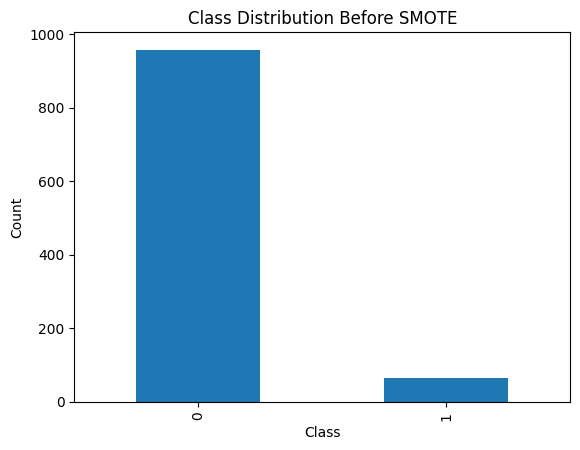

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Count classes
before_counts = pd.Series(y_train).value_counts()

print("Before SMOTE:")
print(before_counts)

# Plot
before_counts.plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

After SMOTE:
0    957
1    957
Name: count, dtype: int64


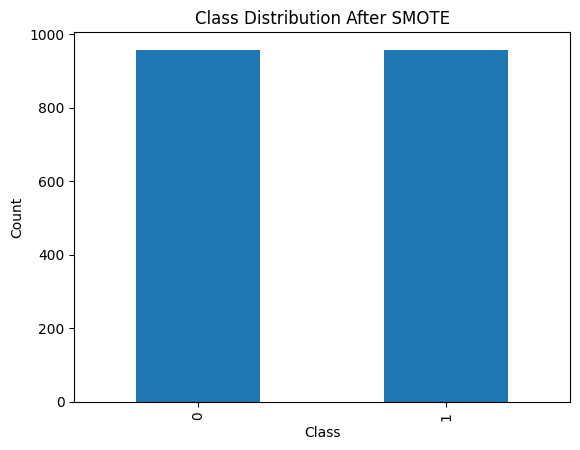

In [18]:
after_counts = pd.Series(y_train_smote).value_counts()

print("After SMOTE:")
print(after_counts)

# Plot
after_counts.plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

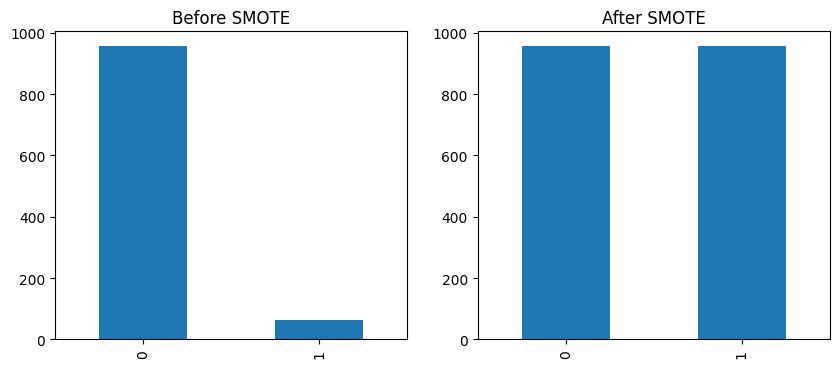

In [19]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

before_counts.plot(kind='bar', ax=ax[0])
ax[0].set_title("Before SMOTE")

after_counts.plot(kind='bar', ax=ax[1])
ax[1].set_title("After SMOTE")

plt.show()

In [24]:
from imblearn.pipeline import Pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=0)),
    ('rf', RandomForestClassifier(random_state=0, n_jobs=-1))
])

# Hyperparameter search space
search_space = {
    'rf__n_estimators': (100, 500),
    'rf__max_depth': (5, 45),
    'rf__min_samples_split': (2, 20),
    'rf__min_samples_leaf': (1, 10),
    'rf__max_features': ['sqrt', 'log2', None]
}



In [25]:
from skopt import BayesSearchCV
opt = BayesSearchCV(
    pipeline,
    search_space,
    n_iter=40,
    cv=5,
    scoring='f1',
    random_state=0,
    n_jobs=-1
)


opt.fit(X_train, y_train)

best_model = opt.best_estimator_
print(best_model)


Pipeline(steps=[('smote', SMOTE(random_state=0)),
                ('rf',
                 RandomForestClassifier(max_depth=45, max_features=None,
                                        min_samples_leaf=8, n_estimators=282,
                                        n_jobs=-1, random_state=0))])


In [26]:

best_model = opt.best_estimator_

y_pred = best_model.predict(X_test)

print("Best Parameters:", opt.best_params_)
print(classification_report(y_test, y_pred))

Best Parameters: OrderedDict({'rf__max_depth': 45, 'rf__max_features': None, 'rf__min_samples_leaf': 8, 'rf__min_samples_split': 2, 'rf__n_estimators': 282})
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       235
           1       0.24      0.29      0.26        21

    accuracy                           0.87       256
   macro avg       0.59      0.60      0.59       256
weighted avg       0.88      0.87      0.87       256

